In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load Dostoevsky corpus

with open("/content/drive/MyDrive/dostoevsky.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Characters:", len(text))
print(text[:500])

Characters: 8234068


===== fyodor-dostoevsky_brothers-karamazov =====


 
 
 
 
 
 
 
 
 
 
 
 

 
The Brothers Karamazov by Fyodor Dostoevsky. 
First published in 1880.  
This translation by Constance Garnett was first published in 1912. 
This ebook edition was created and published by Global Grey in 2019,  
and updated on the 12th April 2023. 
The artwork used for the cover is ‘The Monk-Inok’ 
painted by Konstantin Savitsky. 
This book can be found on the site here: 
32T Uglobalgreyebooks.com/brothers-karamazov-


In [5]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset,DataLoader
class GPTDATASET(Dataset):
  def __init__(self,text,tokenizer,max_len,stride):
    ids = tokenizer.encode(text,allowed_special="all")
    self.x, self.y = [],[]
    for i in range(0,len(ids)-max_len,stride):
      self.x.append(torch.tensor(ids[i : i+max_len]))
      self.y.append(torch.tensor(ids[i+1 : i+max_len+1]))
  def __len__(self):
    return len(self.x)
  def __getitem__(self,i):
    return self.x[i],self.y[i]

In [6]:
def make_loader(text, batch_size=8, max_len=256, stride=256, shuffle=True):
    tok = tiktoken.get_encoding("gpt2")
    ds = GPTDATASET(text, tok, max_len, stride)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
loader = make_loader(text)
X, y = next(iter(loader))

print(X.shape)
print(y.shape)

torch.Size([8, 256])
torch.Size([8, 256])


In [7]:
class CausalSelfAttention(nn.Module):
  def __init__(self,d_model,n_heads,max_len,dropout=0.1):
    super().__init__()
    assert d_model % n_heads == 0
    self.n_heads = n_heads
    self.head_dim = d_model // n_heads
    self.qkv = nn.Linear(d_model,3*d_model,bias=False)
    self.proj = nn.Linear(d_model,d_model)
    self.drop = nn.Dropout(dropout)
    mask = torch.tril(torch.ones(max_len,max_len))
    self.register_buffer("mask",mask.view(1,1,max_len,max_len))

  def forward(self, x):
    B, T, C = x.shape

    q, k, v = self.qkv(x).chunk(3, dim=-1)

    q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
    k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

    scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (B, heads, T, T)
    scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
    weights = self.drop(torch.softmax(scores, dim=-1))

    out = weights @ v                                   # (B, heads, T, head_dim)
    out = out.transpose(1, 2).contiguous().view(B, T, C)
    return self.proj(out)

attn = CausalSelfAttention(d_model=128, n_heads=4, max_len=256)
x = torch.randn(2, 10, 128)
print(attn(x).shape)  # torch.Size([2, 10, 128])

# test 2: causality. Changing a FUTURE token must not change earlier outputs
attn.eval()
x2 = x.clone()
x2[:, 7:] = torch.randn(2, 3, 128)   # alter tokens 7..9
print(torch.allclose(attn(x)[:, :7], attn(x2)[:, :7], atol=1e-6))  # True

torch.Size([2, 10, 128])
True


In [8]:
import torch
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_len, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size=50257, d_model=256, n_heads=4,
                 n_layers=4, max_len=256, dropout=0.1):
        super().__init__()
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(
            *[TransformerBlock(d_model, n_heads, max_len, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight

        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        x = self.blocks(x)
        logits = self.head(self.ln_f(x))

        loss = None
        if targets is not None:
            loss = nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1)
            )
        return logits, loss

# tests
model = GPT()
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

x, y = next(iter(loader))
logits, loss = model(x, y)
print(logits.shape, loss.item())

16.1M params
torch.Size([8, 256, 50257]) 10.886061668395996


In [19]:
import torch, tiktoken


import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)



split = int(0.9 * len(text))

train_text = text[:split]
val_text = text[split:]




train_loader = make_loader(
    train_text,
    batch_size=16,
    max_len=256,
    stride=128,
    shuffle=True
)

val_loader = make_loader(
    val_text,
    batch_size=16,
    max_len=256,
    stride=128,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))



model = GPT().to(device)




checkpoint = torch.load(
    "/content/drive/MyDrive/tinystories_base_model.pt",
    map_location=device
)

model.load_state_dict(checkpoint)

print("TinyStories checkpoint loaded!")


opt = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.1
)




@torch.no_grad()
def evaluate(loader, max_batches=20):

    model.eval()

    losses = []

    for i, (x, y) in enumerate(loader):

        if i >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        _, loss = model(x, y)

        losses.append(loss.item())

    model.train()

    return sum(losses) / len(losses)



epochs = 5
eval_every = 100
step = 0

for epoch in range(epochs):

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        _, loss = model(x, y)

        opt.zero_grad(set_to_none=True)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        opt.step()

        step += 1

        if step % eval_every == 0:

            val_loss = evaluate(val_loader)

            print(
                f"Epoch {epoch+1} | "
                f"Step {step} | "
                f"Train Loss: {loss.item():.3f} | "
                f"Val Loss: {val_loss:.3f}"
            )




torch.save(
    model.state_dict(),
    "dostoevsky_gpt.pt"
)

print("Fine-tuned model saved!")

Training on: cuda
Train batches: 1018
Validation batches: 111
TinyStories checkpoint loaded!
Epoch 1 | Step 100 | Train Loss: 5.868 | Val Loss: 5.827
Epoch 1 | Step 200 | Train Loss: 5.509 | Val Loss: 5.486
Epoch 1 | Step 300 | Train Loss: 5.174 | Val Loss: 5.291
Epoch 1 | Step 400 | Train Loss: 5.050 | Val Loss: 5.151
Epoch 1 | Step 500 | Train Loss: 5.117 | Val Loss: 5.039
Epoch 1 | Step 600 | Train Loss: 4.973 | Val Loss: 4.950
Epoch 1 | Step 700 | Train Loss: 4.944 | Val Loss: 4.877
Epoch 1 | Step 800 | Train Loss: 4.868 | Val Loss: 4.812
Epoch 1 | Step 900 | Train Loss: 4.876 | Val Loss: 4.752
Epoch 1 | Step 1000 | Train Loss: 4.834 | Val Loss: 4.704
Epoch 2 | Step 1100 | Train Loss: 4.775 | Val Loss: 4.656
Epoch 2 | Step 1200 | Train Loss: 4.843 | Val Loss: 4.612
Epoch 2 | Step 1300 | Train Loss: 4.361 | Val Loss: 4.576
Epoch 2 | Step 1400 | Train Loss: 4.938 | Val Loss: 4.542
Epoch 2 | Step 1500 | Train Loss: 4.607 | Val Loss: 4.508
Epoch 2 | Step 1600 | Train Loss: 4.653 | Val 

In [21]:
import torch.nn.functional as F

model.eval()

total_loss = 0
correct = 0
total_tokens = 0

with torch.no_grad():
    for x, y in val_loader:
        # Move data to the correct device (GPU/CPU)
        x = x.to(device)
        y = y.to(device)

        logits, _ = model(x)

        # Loss
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            y.view(-1)
        )

        total_loss += loss.item()

        # -------------------------
        # NEXT TOKEN ACCURACY
        # -------------------------

        predictions = torch.argmax(logits, dim=-1)

        correct += (predictions == y).sum().item()
        total_tokens += y.numel()

val_loss = total_loss / len(val_loader)

val_accuracy = correct / total_tokens

print(f"Val Loss: {val_loss:.3f}")
print(f"Val Accuracy: {val_accuracy * 100:.2f}%")

Val Loss: 4.265
Val Accuracy: 28.72%


In [26]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=50, temperature=0.8, top_k=40):

    model.eval()

    tok = tiktoken.get_encoding("gpt2")

    idx = torch.tensor(
        [tok.encode(prompt, allowed_special="all")],
        device=device
    )

    eos_id = tok.eot_token

    for _ in range(max_new_tokens):

        logits, _ = model(idx[:, -model.max_len:])

        logits = logits[:, -1, :] / temperature

        if top_k:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float("-inf")

        probs = torch.softmax(logits, dim=-1)

        nxt = torch.multinomial(probs, 1)

        idx = torch.cat([idx, nxt], dim=1)

        # Use the pre-resolved eos_id to avoid raising tiktoken special token exceptions
        if nxt.item() == eos_id:
            break

    return tok.decode(idx[0].tolist())



In [30]:
prompts = [
    "The sky was",
    "It was a dark and cold night",
    "I looked at him and said",
    "The old man walked slowly",
    "There was something strange about"
]

for prompt in prompts:
    print("\nPROMPT:", prompt)
    print(generate(model, prompt, max_new_tokens=100,temperature=0.8, top_k=40))


PROMPT: The sky was
The sky was gloomy and silent. But he had to be seen, and the same 
the morning he went to the window, and turned 
was in, and looked at him with a smile on his face. His face turned with a frownkin and 
whhewly, though he was watching, he was standing at the table. He smiled, “I saw that 
I had not gone out on his seat, and he had been sitting there. Oh, in the room,

PROMPT: It was a dark and cold night
It was a dark and cold night. It was not a night to look. 
“I have been a very cold day,” said Shatov, “I’m not afraid of it. You 
don’t know it, of a dream,” Mitya muttered, waving his hand. 
“He’s,” exclaimed the captain. “Oh, it’s dark,” said Mitya, making his 


PROMPT: I looked at him and said
I looked at him and said nothing. “I don’t know you don’t know what.” 
“He is a joke, as though he is a man of a man. He just has a word of a 
the prince, if he is in a heart. And how can he have been an old child, and he is 
for a question; the prince is only a little 

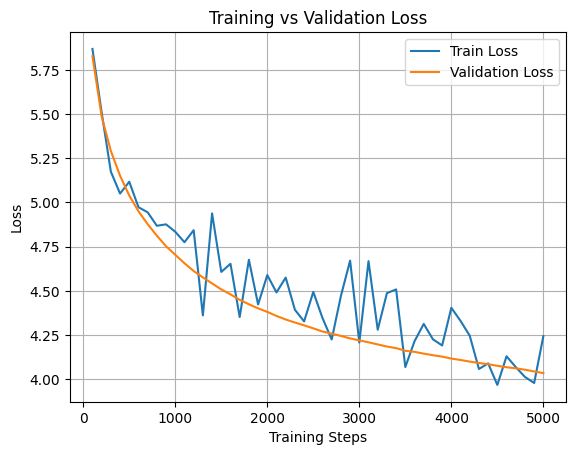

In [23]:
import matplotlib.pyplot as plt

# Reconstruct training and validation metrics from the console logs
train_steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000]
train_losses = [5.868, 5.509, 5.174, 5.050, 5.117, 4.973, 4.944, 4.868, 4.876, 4.834, 4.775, 4.843, 4.361, 4.938, 4.607, 4.653, 4.352, 4.676, 4.423, 4.589, 4.491, 4.575, 4.393, 4.327, 4.494, 4.346, 4.225, 4.471, 4.671, 4.208, 4.668, 4.280, 4.487, 4.508, 4.069, 4.215, 4.313, 4.226, 4.191, 4.404, 4.330, 4.246, 4.058, 4.090, 3.968, 4.130, 4.069, 4.013, 3.979, 4.244]

val_steps = train_steps
val_losses = [5.827, 5.486, 5.291, 5.151, 5.039, 4.950, 4.877, 4.812, 4.752, 4.704, 4.656, 4.612, 4.576, 4.542, 4.508, 4.480, 4.449, 4.424, 4.401, 4.381, 4.358, 4.338, 4.321, 4.305, 4.288, 4.270, 4.258, 4.245, 4.231, 4.220, 4.209, 4.197, 4.185, 4.176, 4.161, 4.155, 4.145, 4.136, 4.128, 4.117, 4.109, 4.100, 4.092, 4.085, 4.076, 4.068, 4.062, 4.054, 4.044, 4.035]

plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()